# Hospital Patient Records Analysis

## Overview
This project analyzes hospital patient data to understand patient flow, hospital workload, treatment patterns, and cost distribution. The dataset consists of multiple related tables including patients, encounters, procedures, and organizations.

## Objectives
- Analyze patient demographics
- Understand hospital encounter patterns
- Evaluate length of stay
- Explore cost distribution
- Identify common procedures

In [89]:
# Import liberaries & Load Data
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/raw")

patients = pd.read_csv(DATA_DIR / "patients.csv")
encounters = pd.read_csv(DATA_DIR / "encounters.csv")
procedures = pd.read_csv(DATA_DIR / "procedures.csv")
organizations = pd.read_csv(DATA_DIR / "organizations.csv")


## Inspect Data Structure
Understanding the shape and columns of each dataset.

In [90]:
print("Patients:", patients.shape)
print("Encounters:", encounters.shape)
print("Procedures:", procedures.shape)
print("Organizations:", organizations.shape)

Patients: (974, 20)
Encounters: (27891, 14)
Procedures: (47701, 9)
Organizations: (1, 8)


In [94]:
display(patients.head())
display(encounters.head())
display(procedures.head())
display(organizations.head())


,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503
1,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162
2,8123d076-0886-9007-e956-d5864aa121a7,1958-06-04,NaN,Mr.,Quinn173,Marquardt819,NaN,NaN,M,white,nonhispanic,M,Gardner Massachusetts US,816 Okuneva Extension Apt 91,Quincy,Massachusetts,Norfolk County,2170.0,42.265177,-70.967085
3,770518e4-6133-648e-60c9-071eb2f0e2ce,1928-12-25,2017-09-29,Mr.,Abel832,Smitham825,NaN,NaN,M,white,hispanic,M,Randolph Massachusetts US,127 Cole Way Unit 95,Boston,Massachusetts,Suffolk County,2118.0,42.334304,-71.066801
4,f96addf5-81b9-0aab-7855-d208d3d352c5,1928-12-25,2014-02-23,Mr.,Edwin773,Labadie908,NaN,NaN,M,white,hispanic,M,Stow Massachusetts US,976 Ziemann Gateway,Boston,Massachusetts,Suffolk County,2125.0,42.346771,-71.058813


,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:24:45Z,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:36:53Z,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04T14:49:55Z,2011-01-04T15:04:55Z,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,363406005.0,Malignant tumor of colon
3,2011-01-05T04:02:09Z,2011-01-05T04:17:09Z,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,173160006,Diagnostic fiberoptic bronchoscopy (procedure),9796,162573006.0,Suspected lung cancer (situation)
4,2011-01-05T12:58:36Z,2011-01-05T16:42:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,265764009,Renal dialysis (procedure),1255,NaN,NaN


,Id,NAME,ADDRESS,CITY,STATE,ZIP,LAT,LON
0,d78e84ec-30aa-3bba-a33a-f29a3a454662,MASSACHUSETTS GENERAL HOSPITAL,55 FRUIT STREET,BOSTON,MA,2114,42.362813,-71.069187


## Data Cleaning
Convert date columns and handle missing values.

In [95]:
patients["BIRTHDATE"] = pd.to_datetime(patients["BIRTHDATE"], errors="coerce")
patients["DEATHDATE"] = pd.to_datetime(patients["DEATHDATE"], errors="coerce")

encounters["START"] = pd.to_datetime(encounters["START"], errors="coerce")
encounters["STOP"] = pd.to_datetime(encounters["STOP"], errors="coerce")

procedures["START"] = pd.to_datetime(procedures["START"], errors="coerce")
procedures["STOP"] = pd.to_datetime(procedures["STOP"], errors="coerce")

## Feature Engineering
Create useful variables such as age, length of stay, and monthly trends.

In [96]:
today = pd.Timestamp.today()

patients["AGE"] = ((today - patients["BIRTHDATE"]).dt.days / 365)

encounters["LENGTH_OF_STAY_HOURS"] = (
    (encounters["STOP"] - encounters["START"]).dt.total_seconds() / 3600
)

encounters["YEAR_MONTH"] = encounters["START"].dt.to_period("M").astype(str)

/tmp/ipykernel_11090/2619063109.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  encounters["YEAR_MONTH"] = encounters["START"].dt.to_period("M").astype(str)


## Data Quality Checks
Check for missing values and data consistency.

In [97]:
display(patients.isna().sum().sort_values(ascending=False).head(10))
display(encounters.isna().sum().sort_values(ascending=False).head(10))
display(procedures.isna().sum().sort_values(ascending=False).head(10))
display(organizations.isna().sum().sort_values(ascending=False).head(10))

SUFFIX       953
DEATHDATE    820
MAIDEN       588
ZIP          142
MARITAL        1
FIRST          0
PREFIX         0
BIRTHDATE      0
Id             0
RACE           0
dtype: int64

REASONCODE           19541
REASONDESCRIPTION    19541
Id                       0
START                    0
ORGANIZATION             0
PAYER                    0
STOP                     0
PATIENT                  0
CODE                     0
ENCOUNTERCLASS           0
dtype: int64

REASONCODE           36945
REASONDESCRIPTION    36945
START                    0
STOP                     0
PATIENT                  0
CODE                     0
ENCOUNTER                0
BASE_COST                0
DESCRIPTION              0
dtype: int64

Id         0
NAME       0
ADDRESS    0
CITY       0
STATE      0
ZIP        0
LAT        0
LON        0
dtype: int64

## Data Relationships (Joins)
Combine tables to enable deeper analysis.

In [98]:
enc_pat = encounters.merge(
    patients,
    left_on="PATIENT",
    right_on="Id",
    how="left",
    suffixes=("_enc", "_pat")
)

enc_org = encounters.merge(
    organizations,
    left_on="ORGANIZATION",
    right_on="Id",
    how="left",
    suffixes=("_enc", "_org")
)

proc_enc = procedures.merge(
    encounters,
    left_on="ENCOUNTER",
    right_on="Id",
    how="left",
    suffixes=("_proc", "_enc")
)

## Join Validation
Ensure relationships between tables are correct.

In [99]:
print("Encounters without matching patient:", enc_pat["Id_pat"].isna().sum())
print("Encounters without matching organization:", enc_org["Id_org"].isna().sum())
print("Procedures without matching encounter:", proc_enc["Id"].isna().sum())

Encounters without matching patient: 0
Encounters without matching organization: 0
Procedures without matching encounter: 0


## Exploratory Data Analysis (Pandas)

In [100]:
display(encounters["ENCOUNTERCLASS"].value_counts())

ENCOUNTERCLASS
ambulatory    12537
outpatient     6300
urgentcare     3666
emergency      2322
wellness       1931
inpatient      1135
Name: count, dtype: int64

### Insight
Outpatient and ambulatory encounters appear to be the most frequent types, indicating high reliance on non-inpatient care.

In [102]:
# Length of Stay
display(encounters["LENGTH_OF_STAY_HOURS"].describe())

count    27891.000000
mean         7.265995
std        398.323624
min          0.250000
25%          0.250000
50%          0.250000
75%          0.864167
max      44930.000000
Name: LENGTH_OF_STAY_HOURS, dtype: float64

### Insight
Length of stay varies widely, with some extreme cases indicating long hospital admissions.

In [103]:
# Cost Analysis
display(encounters.groupby("ENCOUNTERCLASS")["TOTAL_CLAIM_COST"].mean().sort_values(ascending=False))

ENCOUNTERCLASS
inpatient     7761.351841
urgentcare    6369.162564
emergency     4629.651822
wellness      4260.710373
ambulatory    2894.108705
outpatient    2237.296368
Name: TOTAL_CLAIM_COST, dtype: float64

### Insight
Certain encounter types are significantly more expensive, likely due to complexity of care.

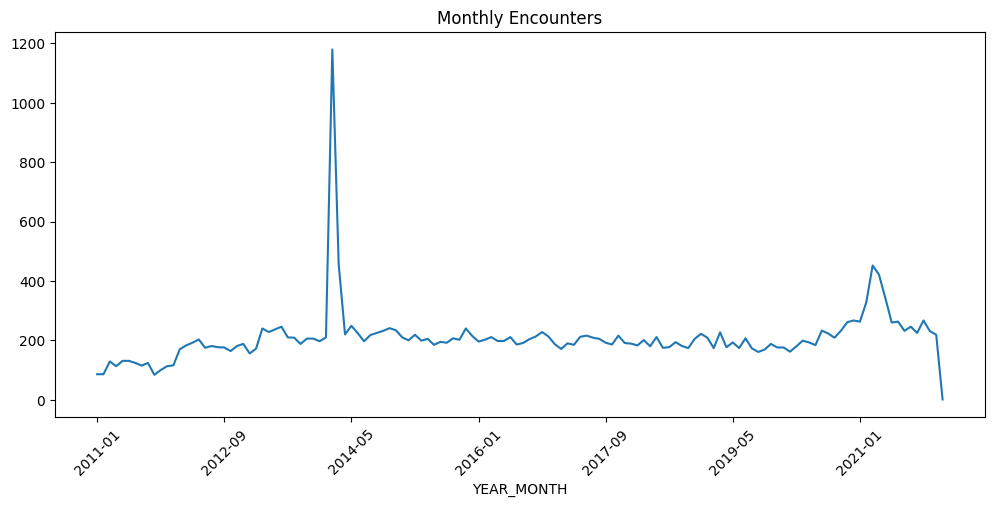

In [104]:
# Monthly Trend
monthly_visits = encounters.groupby("YEAR_MONTH")["Id"].count()

monthly_visits.plot(figsize=(12,5))
plt.title("Monthly Encounters")
plt.xticks(rotation=45)
plt.show()

### Insight
Hospital visits show time-based patterns which may indicate seasonal demand.

In [ ]:
# Encounter Length of stay
encounters["LENGTH_OF_STAY_HOURS"] = (
    (encounters["STOP"] - encounters["START"]).dt.total_seconds() / 3600
)

In [105]:
# Load Cleaned Data into SQLite
import sqlite3
conn = sqlite3.connect("../data/hospital.db")

patients.to_sql("patients", conn, if_exists="replace", index=False)
encounters.to_sql("encounters", conn, if_exists="replace", index=False)
procedures.to_sql("procedures", conn, if_exists="replace", index=False)
organizations.to_sql("organizations", conn, if_exists="replace", index=False)

1

## 10. SQL Analysis

In [106]:
# Encounter Types
sql_encounter_types = pd.read_sql("""
SELECT ENCOUNTERCLASS, COUNT(*) AS total
FROM encounters
GROUP BY ENCOUNTERCLASS
ORDER BY total DESC;
""", conn)

display(sql_encounter_types)

,ENCOUNTERCLASS,total
0,ambulatory,12537
1,outpatient,6300
2,urgentcare,3666
3,emergency,2322
4,wellness,1931
5,inpatient,1135


### Insight
Encounter activity is dominated by specific classes, highlighting operational focus areas.

In [108]:
# Length of Stay
sql_stay = pd.read_sql("""
SELECT ENCOUNTERCLASS, ROUND(AVG(LENGTH_OF_STAY_HOURS),2) AS avg_stay
FROM encounters
GROUP BY ENCOUNTERCLASS;
""", conn)

display(sql_stay)

,ENCOUNTERCLASS,avg_stay
0,ambulatory,9.48
1,emergency,1.54
2,inpatient,36.84
3,outpatient,5.88
4,urgentcare,0.25
5,wellness,0.25


In [109]:
# Top Hospitals
sql_hospitals = pd.read_sql("""
SELECT o.NAME, COUNT(e.Id) AS total
FROM encounters e
LEFT JOIN organizations o ON e.ORGANIZATION = o.Id
GROUP BY o.NAME
ORDER BY total DESC
LIMIT 10;
""", conn)

display(sql_hospitals)

,NAME,total
0,MASSACHUSETTS GENERAL HOSPITAL,27891


### Insight
A small number of hospitals handle the majority of encounters, indicating uneven distribution of workload.

In [110]:
# Top Procedures
sql_proc = pd.read_sql("""
SELECT DESCRIPTION, COUNT(*) AS total
FROM procedures
GROUP BY DESCRIPTION
ORDER BY total DESC
LIMIT 10;
""", conn)

display(sql_proc)

,DESCRIPTION,total
0,Assessment of health and social care needs (pr...,4596
1,Hospice care (regime/therapy),4098
2,Depression screening using Patient Health Ques...,3614
3,Depression screening (procedure),3614
4,Assessment of substance use (procedure),2906
5,Renal dialysis (procedure),2746
6,Assessment using Morse Fall Scale (procedure),2422
7,Assessment of anxiety (procedure),2288
8,Medication Reconciliation (procedure),2284
9,Screening for drug abuse (procedure),1484


## Key Insights
- Patient encounters are concentrated in a few encounter classes.
- Length of stay varies significantly across encounter types.
- A small number of hospitals manage the highest patient volumes.
- Costs differ widely depending on encounter type.
- A limited set of procedures account for most treatments.

## Next Steps

- Build a Power BI dashboard
- Add visual storytelling
- Deploy insights for decision-making

In [111]:
# Export cleaned data
patients.to_csv("../data/processed/patients_clean.csv", index=False)
encounters.to_csv("../data/processed/encounters_clean.csv", index=False)
procedures.to_csv("../data/processed/procedures_clean.csv", index=False)
organizations.to_csv("../data/processed/organizations_clean.csv", index=False)

enc_org.to_csv("../data/processed/encounters_with_organizations.csv", index=False)
enc_pat.to_csv("../data/processed/encounters_with_patients.csv", index=False)
proc_enc.to_csv("../data/processed/procedures_with_encounters.csv", index=False)